In [1]:
import numpy as np
# ... import remaining libraries ...

print("NumPy Version:", np.__version__)

NumPy Version: 2.4.2


# Hands-On Data Lab: Data Analysis & Preprocessing Workflow

## 1. Project Setup & Environment Check

**Objective:** Initialize the Data Science environment, verify package installations, and demonstrate core numerical array operations using **NumPy**.

## 2. NumPy Foundations & Numerical Operations

In this section, we cover:
- Array creation and property inspection
- Reshaping and indexing/slicing
- Vectorized mathematical and statistical operations

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

NumPy Version: 2.4.2
Pandas Version: 2.3.3


In [8]:
arr1d = np.array([10, 20, 30, 40, 50])
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("1D Array:", arr1d)
print("2D Array:\n", arr2d)

1D Array: [10 20 30 40 50]
2D Array:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]


### 2.2 Indexing, Slicing, and Reshaping

**Objective:** Demonstrate element extraction, row/column slicing, and array dimension manipulation using NumPy.

In [10]:
element_6 = arr2d[1, 2]
second_row = arr2d[1]
col_vec = arr1d.reshape(5, 1)
print("Element at row 1, column 2:", element_6)
print("Second row of arr2d:", second_row)
print("Column vector:", col_vec)


Element at row 1, column 2: 6
Second row of arr2d: [4 5 6]
Column vector: [[10]
 [20]
 [30]
 [40]
 [50]]


### 2.3 Mathematical and Statistical Array Operations

**Objective:** Apply vectorized math operations and compute descriptive statistical metrics (mean, sum, standard deviation) using NumPy functions.

In [11]:
# 1. Element-wise multiplication (multiply arr1d by 2)
arr1d_doubled = arr1d * 2

# 2. Statistical calculations on arr1d
mean_val = np.mean(arr1d)
sum_val = np.sum(arr1d)
std_val = np.std(arr1d)

# 3. Column-wise sum of arr2d (across axis=0)
col_sum = arr2d.sum(axis=0)

# Print results
print("Doubled 1D Array:", arr1d_doubled)
print(f"Mean: {mean_val} | Sum: {sum_val} | Standard Deviation: {std_val:.2f}")
print("Column-wise Sum of 2D Array:", col_sum)

Doubled 1D Array: [ 20  40  60  80 100]
Mean: 30.0 | Sum: 150 | Standard Deviation: 14.14
Column-wise Sum of 2D Array: [12 15 18]


## 3. Data Loading, Inspection & Pandas Operations

**Objective:** Load the retail dataset into a Pandas DataFrame, inspect its structure, examine data types, and perform initial filtering and aggregation.

In [1]:
import pandas as pd
import numpy as np

# Create a realistic raw dataset with intentional flaws for cleaning
raw_data = {
    'Transaction_ID': [101, 102, 103, 104, 105, 106, 107, 108, 108, 109, 110], # 108 is duplicate
    'Customer_ID': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C08', 'C09', 'C10'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Electronics', np.nan, 'Home', 'Home', 'Electronics', 'Clothing'],
    'Price': ['250.5', '45.0', '120.0', '85.5', '60.0', '300.0', '150.0', '95.0', '95.0', 'missing', '55.0'], # String mixed with 'missing'
    'Quantity': [2, 1, 3, np.nan, 2, 1, 4, 1, 1, 2, 5], # Missing value
    'Satisfaction_Score': [4.5, 3.8, 4.9, 2.5, 4.0, np.nan, 3.5, 4.2, 4.2, 4.8, 3.0]
}

df = pd.DataFrame(raw_data)

# Save to data directory for reproducibility
df.to_csv('../data/raw_retail_data.csv', index=False)

print("Dataset loaded successfully!")
print("Shape of DataFrame:", df.shape)

Dataset loaded successfully!
Shape of DataFrame: (11, 6)


### 3.2 Dataset Inspection & Data Type Analysis

**Objective:** Inspect the initial rows, summary statistics, structural concise summary (`info()`), and data types of the loaded DataFrame.

In [2]:
# 1. Top 5 rows
print("--- Top 5 Rows ---")
print(df.head())

# 2. DataFrame summary
print("\n--- DataFrame Info ---")
df.info()

# 3. Missing values per column
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

--- Top 5 Rows ---
   Transaction_ID Customer_ID     Category  Price  Quantity  \
0             101         C01  Electronics  250.5       2.0   
1             102         C02     Clothing   45.0       1.0   
2             103         C03  Electronics  120.0       3.0   
3             104         C04         Home   85.5       NaN   
4             105         C05     Clothing   60.0       2.0   

   Satisfaction_Score  
0                 4.5  
1                 3.8  
2                 4.9  
3                 2.5  
4                 4.0  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      11 non-null     int64  
 1   Customer_ID         11 non-null     object 
 2   Category            10 non-null     object 
 3   Price               11 non-null     object 
 4   Quantity            10 non-null  

### 4.1 Identifying and Removing Duplicate Records

**Objective:** Detect duplicate entries within the dataset and drop redundant rows to maintain data integrity.

In [3]:
# Check duplicates count
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Drop duplicates
df = df.drop_duplicates()

# Verify new shape
print("Updated DataFrame Shape:", df.shape)

Number of duplicate rows: 1
Updated DataFrame Shape: (10, 6)


### 4.2 Data Type Conversion & Handling Erroneous Values

**Objective:** Clean non-numeric placeholders in numeric columns and cast string data types to numeric floats.

In [6]:
# 1. Replace 'missing' string with NaN in 'Price' column
df['Price'] = df['Price'].replace('missing', float('nan'))

# 2. Convert 'Price' column to float data type
df['Price'] = df['Price'].astype(float)
print(df.dtypes)
print("\nPrice Column Values:\n", df['Price'])

Transaction_ID          int64
Customer_ID            object
Category               object
Price                 float64
Quantity              float64
Satisfaction_Score    float64
dtype: object

Price Column Values:
 0     250.5
1      45.0
2     120.0
3      85.5
4      60.0
5     300.0
6     150.0
7      95.0
9       NaN
10     55.0
Name: Price, dtype: float64


### 4.3 Imputing Missing Values

**Objective:** Fill missing values in categorical and numerical columns using mode, mean, or median imputation.

In [7]:
# 1. Impute Category with Mode
category_mode = df['Category'].mode()[0]
df['Category'] = df['Category'].fillna(category_mode)

# 2. Impute Price and Quantity with Median
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# 3. Impute Satisfaction_Score with Mean
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(df['Satisfaction_Score'].mean())

# 4. Verify no missing values remain
print("--- Missing Values After Imputation ---")
print(df.isnull().sum())

--- Missing Values After Imputation ---
Transaction_ID        0
Customer_ID           0
Category              0
Price                 0
Quantity              0
Satisfaction_Score    0
dtype: int64


## 5. Feature Engineering & Exploratory Data Analysis (EDA)

**Objective:** Create new calculated features (Total Spend) and compute summary metrics grouped by product category.

In [9]:
# 1. Calculate Total_Spend
df['Total_Spend'] = df['Price'] * df['Quantity']

# 2. Display the updated DataFrame with new feature
print("--- DataFrame with Total_Spend ---")
print(df[['Transaction_ID', 'Category', 'Price', 'Quantity', 'Total_Spend']].head())

# 3. Calculate mean Total_Spend
print("\nAverage Total Spend per Transaction:", df['Total_Spend'].mean())

--- DataFrame with Total_Spend ---
   Transaction_ID     Category  Price  Quantity  Total_Spend
0             101  Electronics  250.5       2.0        501.0
1             102     Clothing   45.0       1.0         45.0
2             103  Electronics  120.0       3.0        360.0
3             104         Home   85.5       2.0        171.0
4             105     Clothing   60.0       2.0        120.0

Average Total Spend per Transaction: 265.7


### 5.2 Grouped Aggregations & Category Insights

**Objective:** Group data by `Category` to calculate total revenue, average satisfaction score, and total units sold.

In [10]:
# Group by Category and aggregate metrics
category_summary = df.groupby('Category').agg(
    Total_Revenue=('Total_Spend', 'sum'),
    Avg_Satisfaction=('Satisfaction_Score', 'mean'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

print("--- Category Performance Summary ---")
print(category_summary)

--- Category Performance Summary ---
      Category  Total_Revenue  Avg_Satisfaction  Total_Quantity
0     Clothing          440.0          3.600000             8.0
1  Electronics         1951.0          4.322222            12.0
2         Home          266.0          3.350000             3.0


## 6. Exploratory Data Visualization

**Objective:** Create visual representations of total revenue and customer satisfaction scores across categories using Matplotlib and Seaborn.

C:\Users\Shivam kumar\AppData\Local\Temp\ipykernel_28368\1834365472.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Shivam kumar\AppData\Local\Temp\ipykernel_28368\1834365472.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


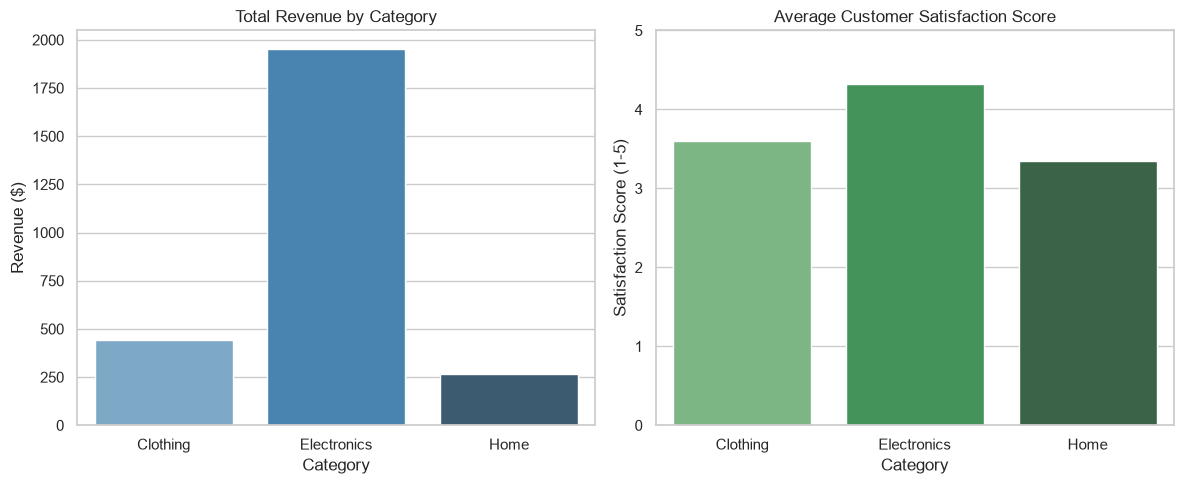

Visualization created and saved to data/category_insights.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Total Revenue by Category
sns.barplot(
    data=category_summary, 
    x='Category', 
    y='Total_Revenue', 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Total Revenue by Category')
axes[0].set_ylabel('Revenue ($)')

# Plot 2: Average Satisfaction Score by Category
sns.barplot(
    data=category_summary, 
    x='Category', 
    y='Avg_Satisfaction', 
    ax=axes[1], 
    palette='Greens_d'
)
axes[1].set_title('Average Customer Satisfaction Score')
axes[1].set_ylabel('Satisfaction Score (1-5)')
axes[1].set_ylim(0, 5)

plt.tight_layout()

# Save figure for documentation
plt.savefig('../data/category_insights.png', dpi=300)
plt.show()

print("Visualization created and saved to data/category_insights.png")

## Lab Results & Key Findings

- **Data Cleaning:** Identified and removed 1 duplicate row, converted `Price` to `float64`, and imputed missing values across `Category`, `Price`, `Quantity`, and `Satisfaction_Score`.
- **Feature Engineering:** Calculated `Total_Spend` per row, yielding an average customer transaction value of **$265.70**.
- **Category Insights:**
  - **Electronics** generated the highest overall revenue (**$1,951.00**) and achieved the highest average satisfaction rating (**4.32**).
  - **Clothing** followed with **$440.00** revenue (**3.60** satisfaction score).
  - **Home** recorded **$266.00** revenue (**3.35** satisfaction score).


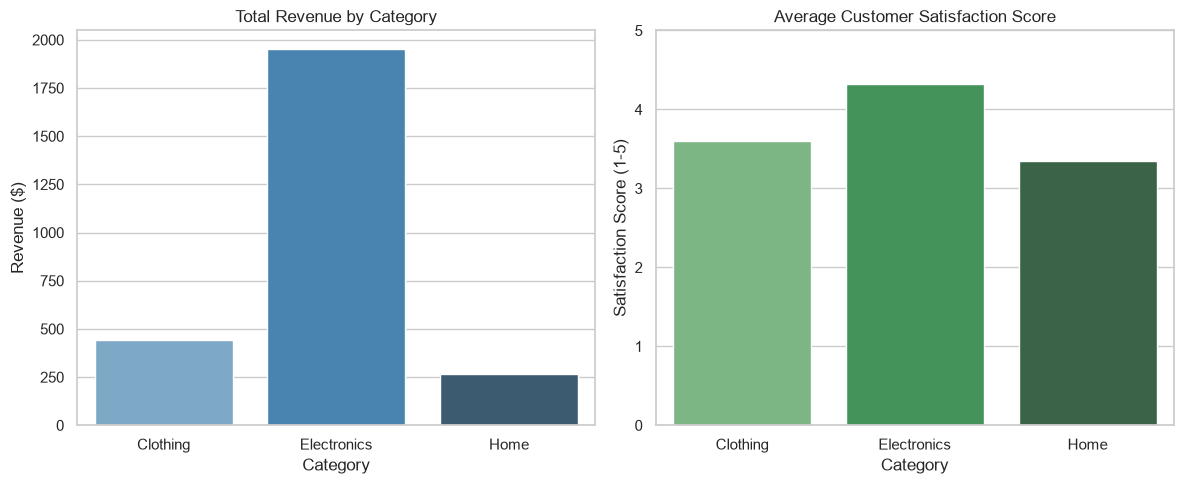

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Total Revenue by Category
sns.barplot(
    data=category_summary, 
    x='Category', 
    y='Total_Revenue', 
    hue='Category',
    legend=False,
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Total Revenue by Category')
axes[0].set_ylabel('Revenue ($)')

# Plot 2: Average Satisfaction Score by Category
sns.barplot(
    data=category_summary, 
    x='Category', 
    y='Avg_Satisfaction', 
    hue='Category',
    legend=False,
    ax=axes[1], 
    palette='Greens_d'
)
axes[1].set_title('Average Customer Satisfaction Score')
axes[1].set_ylabel('Satisfaction Score (1-5)')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('../data/category_insights.png', dpi=300)
plt.show()